In [251]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from config import get_engine
import joblib


In [252]:
OUTPUT_DIR = Path('output')
engine = get_engine()

In [253]:
df=pd.read_csv(OUTPUT_DIR / 'cleaned_master_dataset.csv')
df.head()

,Customer_ID,Geo_ID,Industry_ID,Product_ID,Cluster_Label,Account_Tier,Company_Size,Company_Age_Years,Employees,Legal_Entity_Type,...,Base_Monthly_Price_USD,Included_Licenses,API_Limit_Monthly,SLA_Uptime_Pct,Support_Level,AI_Features_Included,avg_monthly_revenue,revenue_per_employee,licenses_unused,Total_days
0,11177,121,4,27,At-Risk SMB,Platinum,Startup (<50),10,91.0,Ltd,...,4000,500,500000,99.9,Premium,Yes,8.652174,1.450549,6,365
1,14771,44,5,25,High-Growth Startup,Gold,Startup (<50),1,309.0,AG,...,500,25,10000,99.0,Community,No,356.750000,127.113269,107,365
2,11091,6,7,27,High Revenue Loyal,Bronze,Mid-Market (251-1000),7,990.0,GmbH,...,4000,500,500000,99.9,Premium,Yes,1623.492063,69.527273,-59,730
3,14818,1,3,17,At-Risk SMB,Strategic,Startup (<50),2,121.0,LLC,...,500,25,10000,99.0,Community,No,28.772727,75.181818,-11,90
4,14376,19,10,18,High Revenue Loyal,Bronze,SMB (50-250),9,245.0,Sdn Bhd,...,1500,100,100000,99.5,Standard,No,168.640000,57.318367,33,365


In [254]:
customer_ids = df['Customer_ID']

In [255]:
df.drop(columns=['Customer_ID', 'Geo_ID', 'Industry_ID','Product_ID'], inplace=True)

In [256]:
df_cluster = df.drop(columns=[
    # IDs
    # 'Customer_ID','Geo_ID','Industry_ID','Product_ID',,'CSM_Name'
    'CSM_Assigned','Executive_Sponsor','ISO2',
    
    # Target leakage
    'Next_Quarter_Revenue_USD','Churn','Renewal_Probability','Cluster_Label',
    
    # Dates
    'Contract_Start_Date','Contract_End_Date',
    
    # Redundant financials
    'ACV_Local','ACV_USD','Lifetime_Revenue_USD',
    'Net_Revenue_USD_sum','Net_Revenue_USD_mean','Net_Revenue_USD_count',
    'Total_Billed_USD_sum','Last_Invoice_Amount_USD',
    'Subscription_Value_Local','Add_On_Revenue_USD',

    'HQ_vs_Billing', 'CSM_Assigned', 'Executive_Sponsor', 'Onboarding_Completed', 'QBR_Completed_Last_6M', 'Competitor_Mentioned', 'Downsell_Requested', 'Churn', 'AI_Features_Included'
])

In [257]:
corr = df_cluster.select_dtypes(include='number').corr()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
to_drop

['Daily_Active_Users_mean',
 'Daily_Active_Users_std',
 'Daily_Active_Users_last',
 'Feature_Adoption_Pct_mean',
 'Feature_Adoption_Pct_last',
 'API_Calls_Monthly_sum',
 'API_Calls_Monthly_mean',
 'Sessions_Total_sum',
 'Payment_Delay_Days_mean',
 'Payment_Delay_Days_max',
 'Discount_Pct_mean',
 'Included_Licenses',
 'API_Limit_Monthly']

In [258]:
df_cluster.drop(columns=to_drop, inplace=True)
X=df_cluster.copy()

In [259]:
num_cols = df_cluster.select_dtypes(include=['int64','float64']).columns
cat_cols = df_cluster.select_dtypes(include=['object']).columns

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

C:\Users\hello\AppData\Local\Temp\ipykernel_19452\940572682.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_cluster.select_dtypes(include=['object']).columns


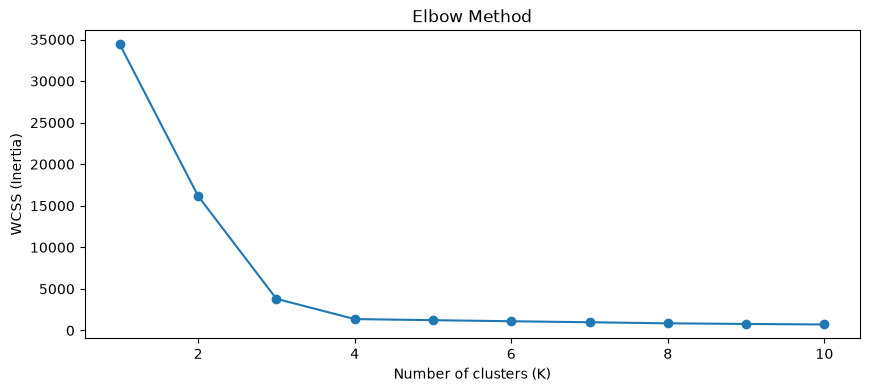

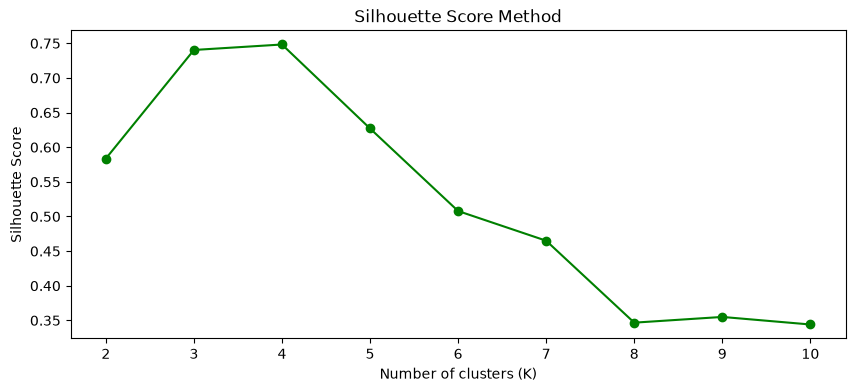

Best K based on silhouette score: 4


In [260]:


# -----------------------------
# 1. Create sample dataset
# (Replace this with your real data)
# -----------------------------
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.2, random_state=42)

# -----------------------------
# 2. Elbow Method (WCSS)
# -----------------------------
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

plt.figure(figsize=(10, 4))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()

# -----------------------------
# 3. Silhouette Score Method
# (Note: K must be >= 2)
# -----------------------------
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.figure(figsize=(10, 4))
plt.plot(range(2, 11), sil_scores, marker='o', color='green')
plt.title("Silhouette Score Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# -----------------------------
# 4. Best K from silhouette
# -----------------------------
best_k = range(2, 11)[sil_scores.index(max(sil_scores))]
print("Best K based on silhouette score:", best_k)

In [261]:
# -----------------------------
#  Transform data
# -----------------------------
X_processed = preprocess.fit_transform(df_cluster)

In [262]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_processed)

In [263]:
df_cluster["Cluster"] = labels

In [264]:
print("\nCluster Summary:")
print(df_cluster.groupby("Cluster").mean(numeric_only=True))


Cluster Summary:
         Company_Age_Years    Employees  Tenure_Months  Health_Score  \
Cluster                                                                
0                 6.197324   479.725753      24.838629     65.686455   
1                 6.070159   449.004677      23.072030     65.253508   
2                 9.481294  1564.822448      59.549144     84.081801   
3                 7.652516   141.327044      24.515723     34.794811   

         Last_Training_Days_Ago  Licenses_Purchased  Daily_Active_Users  \
Cluster                                                                   
0                     73.257525           90.400502           69.423077   
1                     73.436857           92.314312           70.049579   
2                     29.370323          194.268231          149.255549   
3                    174.510220           40.420597           30.113994   

         Feature_Adoption_Pct  API_Calls_Monthly  Mobile_Users_Pct  ...  \
Cluster                

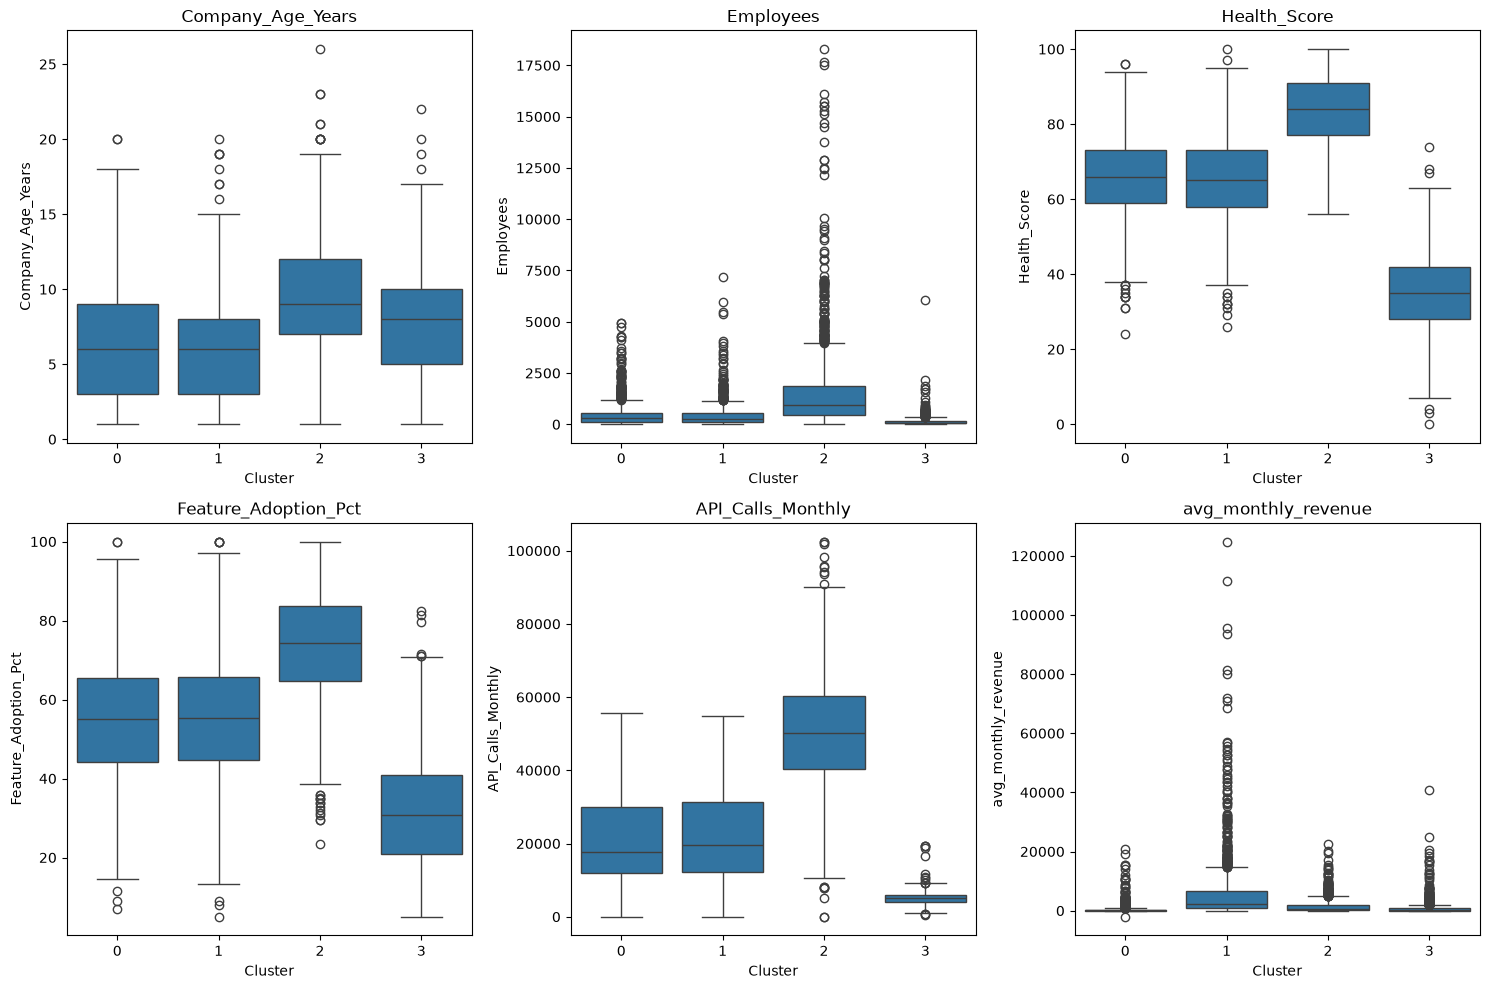

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "Company_Age_Years",
    "Employees",
    "Health_Score",
    "Feature_Adoption_Pct",
    "API_Calls_Monthly",
    "avg_monthly_revenue"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="Cluster", y=col, data=df_cluster)
    plt.title(col)

plt.tight_layout()
plt.show()

In [266]:
cluster_map = {
    0: "Mid-Tier Active Customers",
    1: "High-Revenue Enterprise Customers",
    2: "High-Value Growth Customers",
    3: "At-Risk Low Engagement Customers"
}

df_cluster["Cluster_Name"] = df_cluster["Cluster"].map(cluster_map)

In [267]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_processed)

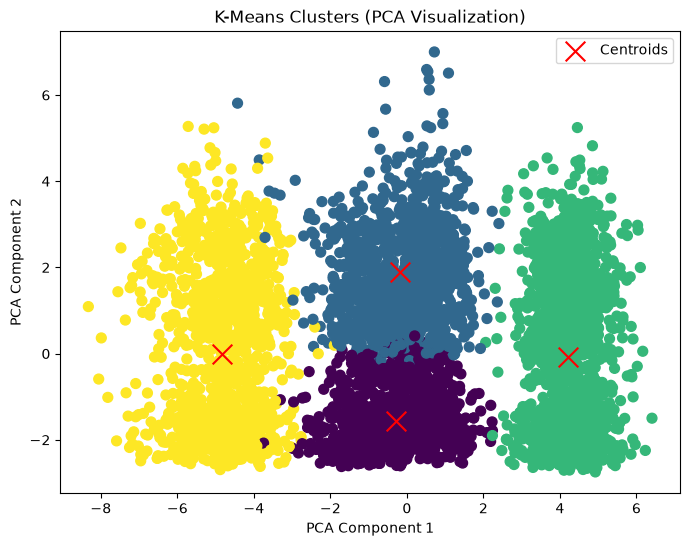

In [268]:
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=50)

plt.title("K-Means Clusters (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# plot centroids
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='x', s=200, label='Centroids')

plt.legend()
plt.show()

In [269]:
df_cluster.to_csv(OUTPUT_DIR / 'customer_segments.csv', index=False)

In [270]:
# -----------------------------
# Save the fitted objects
# -----------------------------
joblib.dump(preprocess, OUTPUT_DIR / 'segmentation_preprocess.pkl')  # Saves ColumnTransformer
joblib.dump(kmeans, OUTPUT_DIR / 'segmentation_kmeans.pkl')          # Saves fitted KMeans
df_cluster.to_csv(OUTPUT_DIR / 'customer_segments.csv', index=False) # Saves labeled data

print("Saved:")
print(f" - {OUTPUT_DIR / 'segmentation_preprocess.pkl'}  <- Use this to transform new customers")
print(f" - {OUTPUT_DIR / 'segmentation_kmeans.pkl'}      <- Use this to predict clusters")
print(f" - {OUTPUT_DIR / 'customer_segments.csv'}        <- Your labeled training data")

Saved:
 - output\segmentation_preprocess.pkl  <- Use this to transform new customers
 - output\segmentation_kmeans.pkl      <- Use this to predict clusters
 - output\customer_segments.csv        <- Your labeled training data


In [276]:
cluster_names = {
    0: "Mid-Tier Active Customers",
    1: "High-Revenue Enterprise Customers",
    2: "High-Value Growth Customers",
    3: "At-Risk Low Engagement Customers"
}


In [277]:
segment_output = pd.DataFrame({
    'Customer_ID': customer_ids.values,
    'Cluster': labels
})

segment_output['Cluster_Name'] = segment_output['Cluster'].map(cluster_names)

In [278]:
segment_output.to_csv(
    'customer_segments_labeled.csv',
    index=False
)

print(segment_output.head())

   Customer_ID  Cluster                       Cluster_Name
0        11177        3   At-Risk Low Engagement Customers
1        14771        1  High-Revenue Enterprise Customers
2        11091        2        High-Value Growth Customers
3        14818        3   At-Risk Low Engagement Customers
4        14376        2        High-Value Growth Customers
